In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")

In [2]:
!pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
file_path = r"D:\Universities Proj\Online Retail\Online Retail.xlsx"
df = pd.read_excel(file_path)
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [4]:
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
print(df[df['Description'].isnull()].head(10))
print(df[df['CustomerID'].isnull()].head(10))

     InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
622     536414     22139         NaN        56 2010-12-01 11:52:00       0.00   
1970    536545     21134         NaN         1 2010-12-01 14:32:00       0.00   
1971    536546     22145         NaN         1 2010-12-01 14:33:00       0.00   
1972    536547     37509         NaN         1 2010-12-01 14:33:00       0.00   
1987    536549    85226A         NaN         1 2010-12-01 14:34:00       0.00   
1988    536550     85044         NaN         1 2010-12-01 14:34:00       0.00   
2024    536552     20950         NaN         1 2010-12-01 14:34:00       0.00   
2025    536553     37461         NaN         3 2010-12-01 14:35:00       0.00   
2026    536554     84670         NaN        23 2010-12-01 14:35:00       0.00   
2406    536589     21777         NaN       -10 2010-12-01 16:50:00       0.00   

      CustomerID         Country  
622          NaN  United Kingdom  
1970         NaN  United Kingdom  
197

In [7]:
df = df.dropna(subset=['Description'])

print(df.shape)
print(df.isnull().sum())

(540455, 8)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


In [8]:
print(f"Quantity zero: {(df['Quantity'] == 0).sum()}")
print(f"Quantity negative: {(df['Quantity'] < 0).sum()}")
print(f"UnitPrice zero: {(df['UnitPrice'] == 0).sum()}")
print(f"UnitPrice negative: {(df['UnitPrice'] < 0).sum()}")

Quantity zero: 0
Quantity negative: 9762
UnitPrice zero: 1061
UnitPrice negative: 2


In [9]:
print(df[df['Quantity'] < 0].head(10))
print(df[df['UnitPrice'] == 0].head(10))
print(df[df['UnitPrice'] < 0].head(10))

    InvoiceNo StockCode                        Description  Quantity  \
141   C536379         D                           Discount        -1   
154   C536383    35004C    SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556     PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984   PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983   PACK OF 12 BLUE PAISLEY TISSUES        -24   
238   C536391     21980  PACK OF 12 RED RETROSPOT TISSUES        -24   
239   C536391     21484        CHICK GREY HOT WATER BOTTLE       -12   
240   C536391     22557   PLASTERS IN TIN VINTAGE PAISLEY        -12   
241   C536391     22553             PLASTERS IN TIN SKULLS       -24   
939   C536506     22960           JAM MAKING SET WITH JARS        -6   

            InvoiceDate  UnitPrice  CustomerID         Country  
141 2010-12-01 09:41:00      27.50    14527.00  United Kingdom  
154 2010-12-01 09:49:00       4.65    15311.00  United Kingdom  
235 2010-12-

In [11]:
negative_qty = df[df['Quantity'] < 0].copy()
negative_qty['InvoiceNo'] = negative_qty['InvoiceNo'].astype(str)

c_invoices = negative_qty['InvoiceNo'].str.startswith('C').sum()
non_c_invoices = (~negative_qty['InvoiceNo'].str.startswith('C')).sum()

print(f"Negative quantity with C: {c_invoices}")
print(f"Negative quantity without C: {non_c_invoices}")
print(negative_qty[~negative_qty['InvoiceNo'].str.startswith('C')].head(10))

Negative quantity with C: 9288
Negative quantity without C: 474
      InvoiceNo StockCode                 Description  Quantity  \
7313     537032     21275                           ?       -30   
13217    537425    84968F                       check       -20   
13218    537426    84968E                       check       -35   
13264    537432    35833G                     damages       -43   
21338    538072     22423                      faulty       -13   
21518    538090     20956                           ?      -723   
22296    538161    46000S                Dotcom sales      -100   
22297    538162    46000M                Dotcom sales      -100   
42564    540010     22501  reverse 21/5/10 adjustment      -100   
42566    540012     22502  reverse 21/5/10 adjustment      -100   

              InvoiceDate  UnitPrice  CustomerID         Country  
7313  2010-12-03 16:50:00       0.00         NaN  United Kingdom  
13217 2010-12-06 15:35:00       0.00         NaN  United Kingdom

In [12]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(df.shape)
print(df.isnull().sum())

(530104, 8)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64


In [13]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df[df.duplicated()].head(10)

Duplicate rows: 5226


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.00,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.00,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.00,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.00,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.00,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.00,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.00,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.00,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.00,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.00,United Kingdom


In [14]:
dup_mask = df.duplicated(keep=False)
df_dups = df[dup_mask].sort_values(by=['InvoiceNo', 'StockCode'])
print(df_dups.head(20))

    InvoiceNo StockCode                          Description  Quantity  \
494    536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866          UNION JACK FLAG LUGGAGE TAG         1   
485    536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
539    536409     22111         SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866        HAND WARMER SCOTTY DOG DESIGN         1   
527    536409     22866        HAND WARMER SCOTTY DOG DESIGN         1   
521    536409     22900      SET 2 TEA TOWELS I LOVE LONDON          1   
537    536409     22900      SET 2 TEA TOWELS I LOVE LONDON          1   
565    536412     21448            12 DAISY PEGS IN WOOD BOX         2   
578    536412     21448            12 DAISY PEGS IN WOOD BOX         1   
598    536412     21448            12 DAISY PEGS IN WOOD BOX         1   
601    536412     21448            12 DAISY PEGS IN WOOD BOX         2   
604    536412     21448            12 

In [15]:
df = df.drop_duplicates()

print(f"Shape after removing duplicates: {df.shape}")
print(f"Remaining nulls:\n{df.isnull().sum()}")

Shape after removing duplicates: (524878, 8)
Remaining nulls:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64


In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

print(df[['InvoiceDate', 'TotalPrice', 'Year', 'Month', 'Day', 'DayOfWeek']].head(10))
print(df['TotalPrice'].describe())

          InvoiceDate  TotalPrice  Year  Month  Day  DayOfWeek
0 2010-12-01 08:26:00       15.30  2010     12    1          2
1 2010-12-01 08:26:00       20.34  2010     12    1          2
2 2010-12-01 08:26:00       22.00  2010     12    1          2
3 2010-12-01 08:26:00       20.34  2010     12    1          2
4 2010-12-01 08:26:00       20.34  2010     12    1          2
5 2010-12-01 08:26:00       15.30  2010     12    1          2
6 2010-12-01 08:26:00       25.50  2010     12    1          2
7 2010-12-01 08:28:00       11.10  2010     12    1          2
8 2010-12-01 08:28:00       11.10  2010     12    1          2
9 2010-12-01 08:34:00       54.08  2010     12    1          2
count   524878.00
mean        20.28
std        271.69
min          0.00
25%          3.90
50%          9.92
75%         17.70
max     168469.60
Name: TotalPrice, dtype: float64


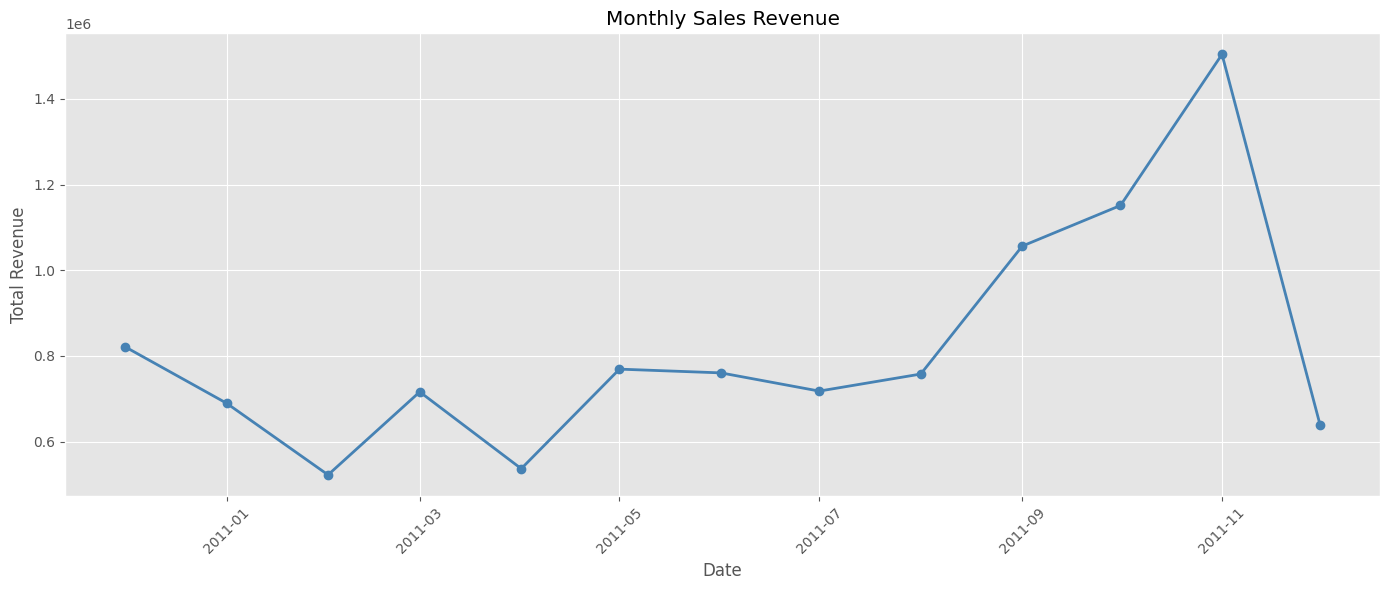

    Year  Month  TotalPrice       Date
0   2010     12   821452.73 2010-12-01
1   2011      1   689811.61 2011-01-01
2   2011      2   522545.56 2011-02-01
3   2011      3   716215.26 2011-03-01
4   2011      4   536968.49 2011-04-01
5   2011      5   769296.61 2011-05-01
6   2011      6   760547.01 2011-06-01
7   2011      7   718076.12 2011-07-01
8   2011      8   757841.38 2011-08-01
9   2011      9  1056435.19 2011-09-01
10  2011     10  1151263.73 2011-10-01
11  2011     11  1503866.78 2011-11-01
12  2011     12   637790.33 2011-12-01


In [17]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_sales)

In [18]:
dec_2011 = df[(df['Year'] == 2011) & (df['Month'] == 12)]
print(f"Last date in dataset: {df['InvoiceDate'].max()}")
print(f"December 2011 days covered: {dec_2011['Day'].unique()}")

Last date in dataset: 2011-12-09 12:50:00
December 2011 days covered: [1 2 4 5 6 7 8 9]


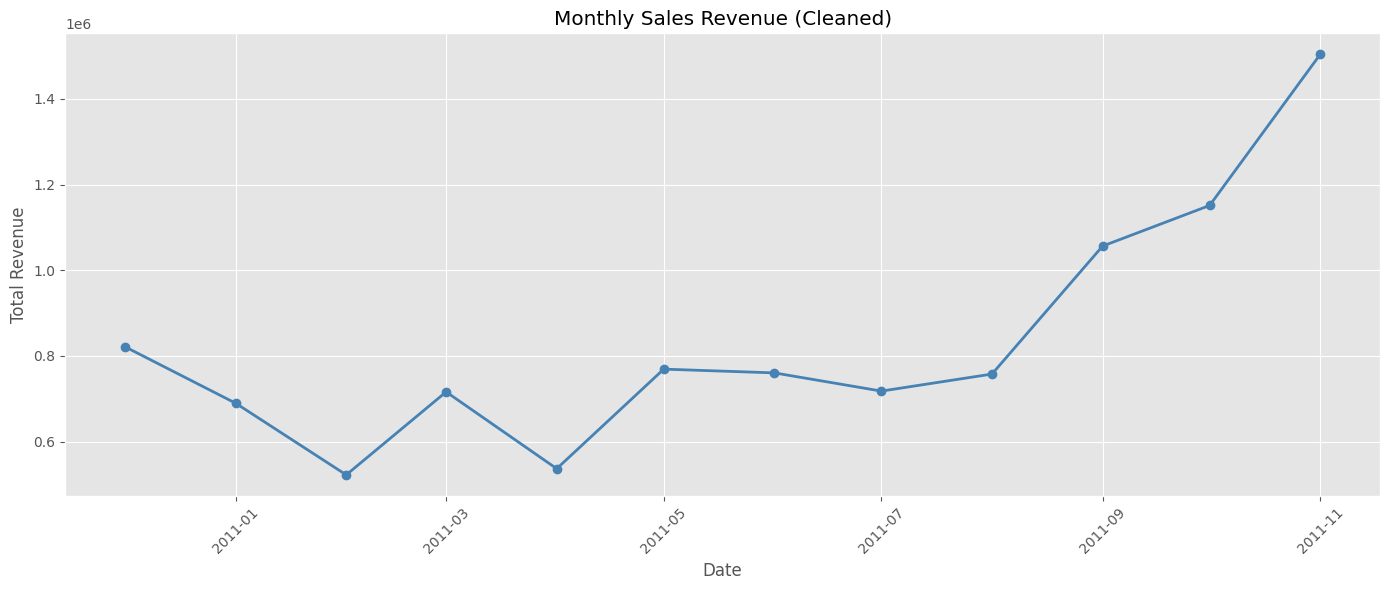

    Year  Month  TotalPrice       Date
0   2010     12   821452.73 2010-12-01
1   2011      1   689811.61 2011-01-01
2   2011      2   522545.56 2011-02-01
3   2011      3   716215.26 2011-03-01
4   2011      4   536968.49 2011-04-01
5   2011      5   769296.61 2011-05-01
6   2011      6   760547.01 2011-06-01
7   2011      7   718076.12 2011-07-01
8   2011      8   757841.38 2011-08-01
9   2011      9  1056435.19 2011-09-01
10  2011     10  1151263.73 2011-10-01
11  2011     11  1503866.78 2011-11-01


In [19]:
df = df[~((df['Year'] == 2011) & (df['Month'] == 12))]

monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Date'], monthly_sales['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Revenue (Cleaned)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly_sales)

In [20]:
for year in [2010, 2011]:
    for month in [2, 4]:
        data = df[(df['Year'] == year) & (df['Month'] == month)]
        if len(data) > 0:
            print(f"{year}-{month:02d}: days covered = {sorted(data['Day'].unique())}")

2011-02: days covered = [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28]
2011-04: days covered = [1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 26, 27, 28]


In [21]:
monthly_sales['Lag1'] = monthly_sales['TotalPrice'].shift(1)
monthly_sales['Lag2'] = monthly_sales['TotalPrice'].shift(2)
monthly_sales['Lag3'] = monthly_sales['TotalPrice'].shift(3)
monthly_sales['RollingMean3'] = monthly_sales['TotalPrice'].shift(1).rolling(3).mean()
monthly_sales['RollingStd3'] = monthly_sales['TotalPrice'].shift(1).rolling(3).std()

monthly_sales = monthly_sales.dropna()

print(monthly_sales)

    Year  Month  TotalPrice       Date       Lag1       Lag2      Lag3  \
3   2011      3   716215.26 2011-03-01  522545.56  689811.61 821452.73   
4   2011      4   536968.49 2011-04-01  716215.26  522545.56 689811.61   
5   2011      5   769296.61 2011-05-01  536968.49  716215.26 522545.56   
6   2011      6   760547.01 2011-06-01  769296.61  536968.49 716215.26   
7   2011      7   718076.12 2011-07-01  760547.01  769296.61 536968.49   
8   2011      8   757841.38 2011-08-01  718076.12  760547.01 769296.61   
9   2011      9  1056435.19 2011-09-01  757841.38  718076.12 760547.01   
10  2011     10  1151263.73 2011-10-01 1056435.19  757841.38 718076.12   
11  2011     11  1503866.78 2011-11-01 1151263.73 1056435.19 757841.38   

    RollingMean3  RollingStd3  
3      677936.63    149806.99  
4      642857.48    105026.22  
5      591909.77    107892.99  
6      674160.12    121739.74  
7      688937.37    131681.60  
8      749306.58     27397.90  
9      745488.17     23778.05  
10 

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'RollingStd3', 'Month']

train = monthly_sales[monthly_sales['Date'] < '2011-11-01']
test = monthly_sales[monthly_sales['Date'] == '2011-11-01']

X_train = train[features]
y_train = train['TotalPrice']

X_test = test[features]
y_test = test['TotalPrice']

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_train, model.predict(X_train))
    print(f"\n{name}:")
    print(f"Predicted: {y_pred[0]:,.2f}")
    print(f"Actual:    {y_test.values[0]:,.2f}")
    print(f"MAE:       {mae:,.2f}")
    print(f"R2 (train): {r2:.2f}")


Linear Regression:
Predicted: 933,686.06
Actual:    1,503,866.78
MAE:       570,180.72
R2 (train): 0.94

Random Forest:
Predicted: 1,042,927.68
Actual:    1,503,866.78
MAE:       460,939.10
R2 (train): 0.87

Gradient Boosting:
Predicted: 1,139,002.51
Actual:    1,503,866.78
MAE:       364,864.27
R2 (train): 1.00


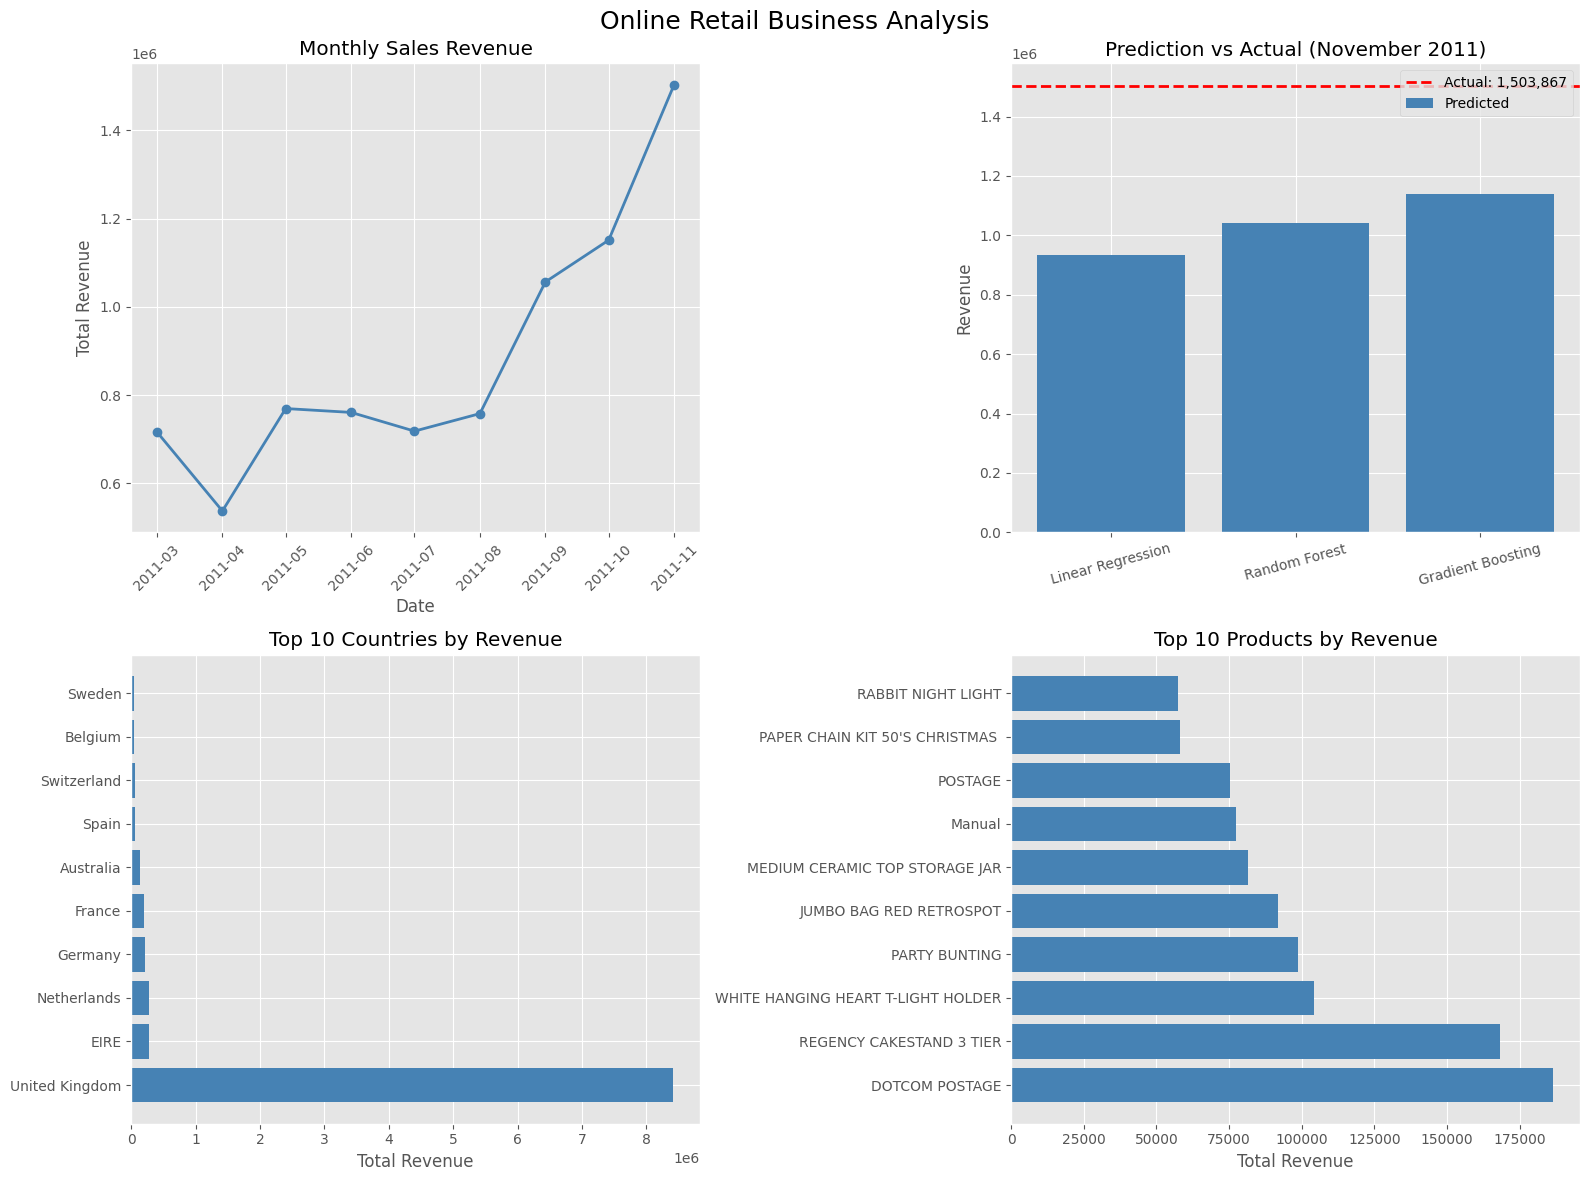

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Online Retail Business Analysis', fontsize=18)

# 1. monthly sales trend
axes[0, 0].plot(monthly_sales['Date'], monthly_sales['TotalPrice'], 
                marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('Monthly Sales Revenue')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Revenue')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. prediction vs actual
models_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
predictions = [933686.06, 1042927.68, 1139002.51]
actual = 1503866.78

x = range(len(models_names))
axes[0, 1].bar(x, predictions, color='steelblue', label='Predicted')
axes[0, 1].axhline(y=actual, color='red', linestyle='--', linewidth=2, label=f'Actual: {actual:,.0f}')
axes[0, 1].set_title('Prediction vs Actual (November 2011)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_names, rotation=15)
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].legend()

# 3. top 10 countries by revenue
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1, 0].barh(top_countries.index, top_countries.values, color='steelblue')
axes[1, 0].set_title('Top 10 Countries by Revenue')
axes[1, 0].set_xlabel('Total Revenue')

# 4. top 10 products by revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1, 1].barh(top_products.index, top_products.values, color='steelblue')
axes[1, 1].set_title('Top 10 Products by Revenue')
axes[1, 1].set_xlabel('Total Revenue')

plt.tight_layout()
plt.savefig(r"D:\Universities Proj\Online Retail\business_analysis.png", dpi=150)
plt.show()

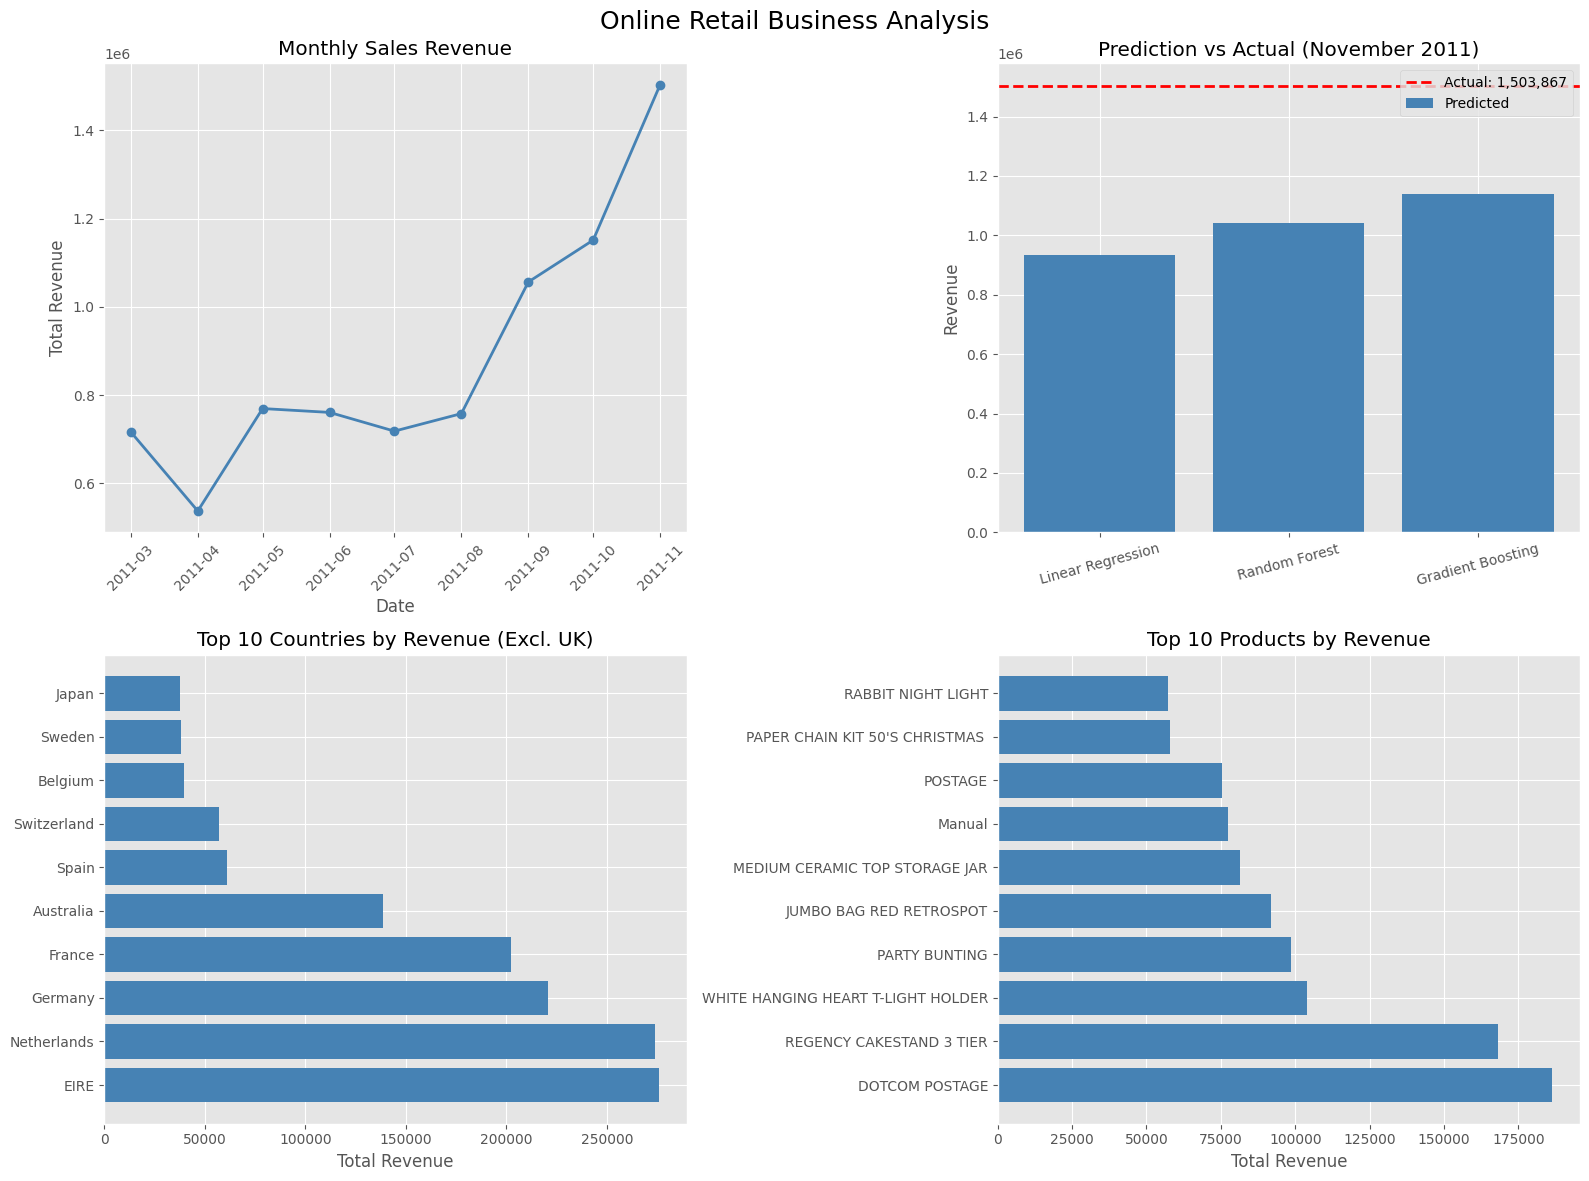

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Online Retail Business Analysis', fontsize=18)

# 1. monthly sales trend
axes[0, 0].plot(monthly_sales['Date'], monthly_sales['TotalPrice'],
                marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('Monthly Sales Revenue')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Revenue')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. prediction vs actual
models_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
predictions = [933686.06, 1042927.68, 1139002.51]
actual = 1503866.78
x = range(len(models_names))
axes[0, 1].bar(x, predictions, color='steelblue', label='Predicted')
axes[0, 1].axhline(y=actual, color='red', linestyle='--', linewidth=2, label=f'Actual: {actual:,.0f}')
axes[0, 1].set_title('Prediction vs Actual (November 2011)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_names, rotation=15)
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].legend()

# 3. top 10 countries excluding UK
top_countries = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1, 0].barh(top_countries.index, top_countries.values, color='steelblue')
axes[1, 0].set_title('Top 10 Countries by Revenue (Excl. UK)')
axes[1, 0].set_xlabel('Total Revenue')

# 4. top 10 products by revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1, 1].barh(top_products.index, top_products.values, color='steelblue')
axes[1, 1].set_title('Top 10 Products by Revenue')
axes[1, 1].set_xlabel('Total Revenue')

plt.tight_layout()
plt.savefig(r"D:\Universities Proj\Online Retail\business_analysis.png", dpi=150)
plt.show()

In [25]:
dec_features = {
    'Lag1': 1503866.78,
    'Lag2': 1151263.73,
    'Lag3': 1056435.19,
    'RollingMean3': (1503866.78 + 1151263.73 + 1056435.19) / 3,
    'RollingStd3': pd.Series([1503866.78, 1151263.73, 1056435.19]).std(),
    'Month': 12
}

X_dec = pd.DataFrame([dec_features])

print("December 2011 Predictions:")
for name, model in models.items():
    pred = model.predict(X_dec)[0]
    print(f"{name}: {pred:,.2f}")

December 2011 Predictions:
Linear Regression: 785,181.89
Random Forest: 1,042,511.42
Gradient Boosting: 1,139,002.51


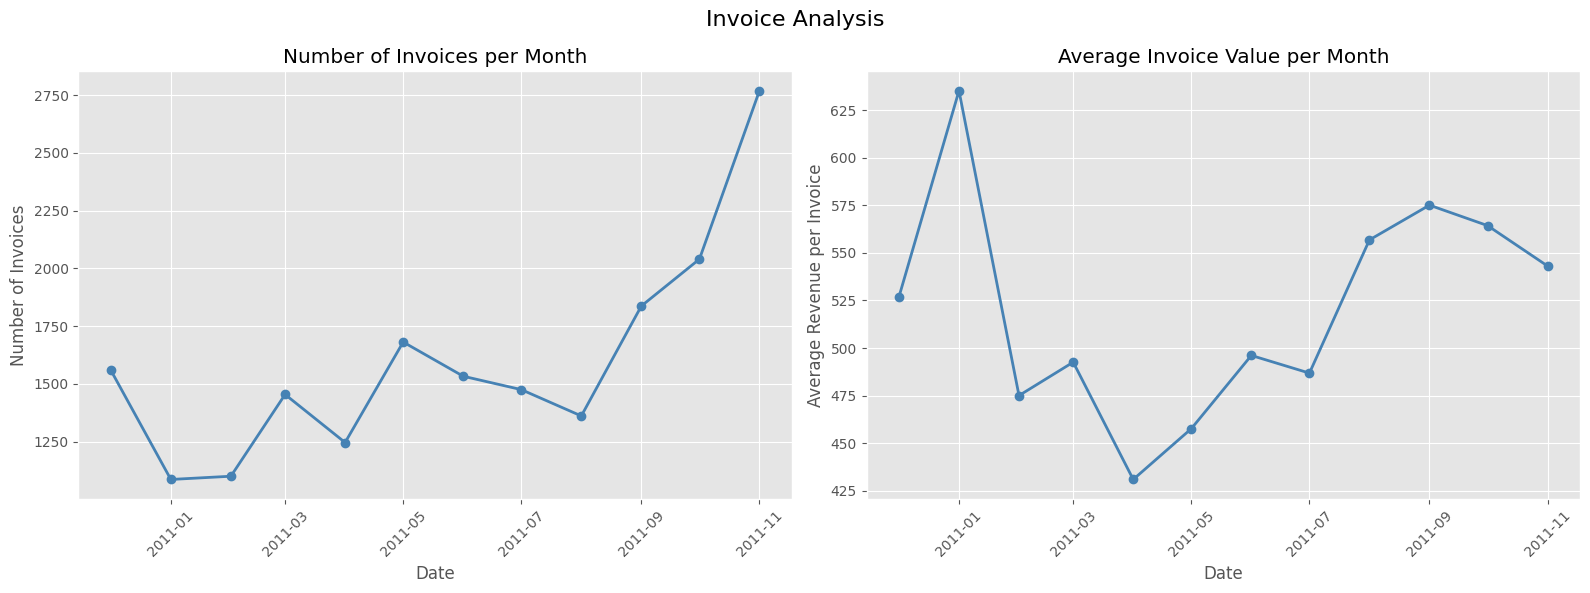

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Invoice Analysis', fontsize=16)

# 1. number of invoices per month
monthly_invoices = df.groupby(['Year', 'Month'])['InvoiceNo'].nunique().reset_index()
monthly_invoices['Date'] = pd.to_datetime(monthly_invoices[['Year', 'Month']].assign(Day=1))
monthly_invoices = monthly_invoices[monthly_invoices['Date'] < '2011-12-01']
monthly_invoices = monthly_invoices.sort_values('Date')

axes[0].plot(monthly_invoices['Date'], monthly_invoices['InvoiceNo'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Number of Invoices per Month')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Invoices')
axes[0].tick_params(axis='x', rotation=45)

# 2. average invoice value per month
monthly_avg = df.groupby(['Year', 'Month', 'InvoiceNo'])['TotalPrice'].sum().reset_index()
monthly_avg = monthly_avg.groupby(['Year', 'Month'])['TotalPrice'].mean().reset_index()
monthly_avg['Date'] = pd.to_datetime(monthly_avg[['Year', 'Month']].assign(Day=1))
monthly_avg = monthly_avg[monthly_avg['Date'] < '2011-12-01']
monthly_avg = monthly_avg.sort_values('Date')

axes[1].plot(monthly_avg['Date'], monthly_avg['TotalPrice'],
             marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Average Invoice Value per Month')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Revenue per Invoice')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r"D:\Universities Proj\Online Retail\invoice_analysis.png", dpi=150)
plt.show()

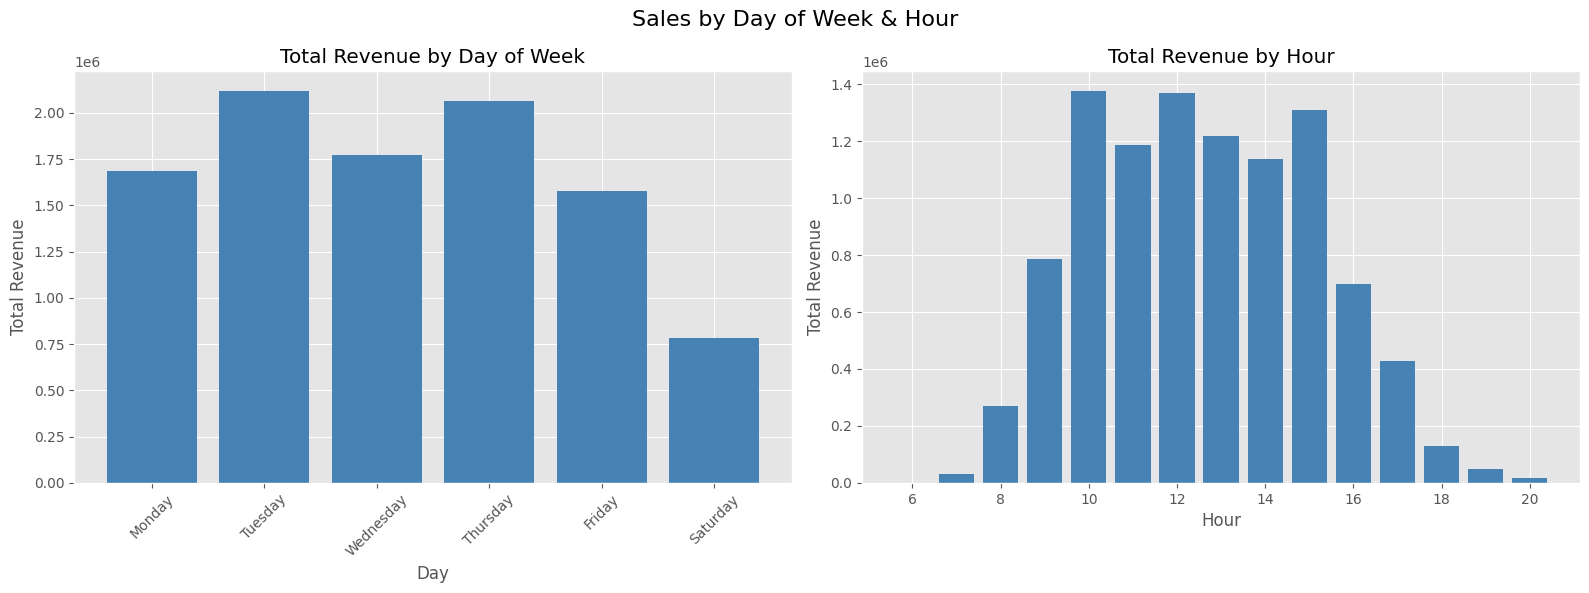

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sales by Day of Week & Hour', fontsize=16)

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. sales by day of week
day_sales = df.groupby('DayOfWeek')['TotalPrice'].sum()
axes[0].bar(day_names[:len(day_sales)], day_sales.values, color='steelblue')
axes[0].set_title('Total Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=45)

# 2. sales by hour
df['Hour'] = df['InvoiceDate'].dt.hour
hour_sales = df.groupby('Hour')['TotalPrice'].sum()
axes[1].bar(hour_sales.index, hour_sales.values, color='steelblue')
axes[1].set_title('Total Revenue by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.savefig(r"D:\Universities Proj\Online Retail\day_hour_analysis.png", dpi=150)
plt.show()